In [2]:
import zipfile
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import requests

DATA_DIR = Path("../data")
RAW_DIR = DATA_DIR / "raw"
RAW_DIR.mkdir(parents=True, exist_ok=True)

zip_url = "https://archive.ics.uci.edu/static/public/179/secom.zip"
zip_path = RAW_DIR / "secom.zip"

if not zip_path.exists():
    response = requests.get(zip_url)
    response.raise_for_status()
    zip_path.write_bytes(response.content)

with zipfile.ZipFile(zip_path, "r") as zf:
    zf.extractall(RAW_DIR)

X = pd.read_csv(
    RAW_DIR / "secom.data",
    sep=r"\s+",
    header=None,
    na_values="NaN",
)

labels = pd.read_csv(
    RAW_DIR / "secom_labels.data",
    sep=r"\s+",
    header=None,
    names=["label", "timestamp"],
)

y = labels[["label"]]

print("X shape:", X.shape)
print("y shape:", y.shape)

display(y.head())
display(X.head())

X shape: (1567, 590)
y shape: (1567, 1)


,label
0,-1
1,-1
2,1
3,-1
4,-1


,0,1,2,3,4,5,6,7,8,9,...,580,581,582,583,584,585,586,587,588,589
0,3030.93,2564.00,2187.7333,1411.1265,1.3602,100.0,97.6133,0.1242,1.5005,0.0162,...,NaN,NaN,0.5005,0.0118,0.0035,2.3630,NaN,NaN,NaN,NaN
1,3095.78,2465.14,2230.4222,1463.6606,0.8294,100.0,102.3433,0.1247,1.4966,-0.0005,...,0.0060,208.2045,0.5019,0.0223,0.0055,4.4447,0.0096,0.0201,0.0060,208.2045
2,2932.61,2559.94,2186.4111,1698.0172,1.5102,100.0,95.4878,0.1241,1.4436,0.0041,...,0.0148,82.8602,0.4958,0.0157,0.0039,3.1745,0.0584,0.0484,0.0148,82.8602
3,2988.72,2479.90,2199.0333,909.7926,1.3204,100.0,104.2367,0.1217,1.4882,-0.0124,...,0.0044,73.8432,0.4990,0.0103,0.0025,2.0544,0.0202,0.0149,0.0044,73.8432
4,3032.24,2502.87,2233.3667,1326.5200,1.5334,100.0,100.3967,0.1235,1.5031,-0.0031,...,NaN,NaN,0.4800,0.4766,0.1045,99.3032,0.0202,0.0149,0.0044,73.8432


In [ ]:
## -1 = pass / 1 = fail

target_col = y.columns[0]

label_counts = y[target_col].value_counts().sort_index()
label_ratio = y[target_col].value_counts(normalize=True).sort_index()

label_summary = pd.DataFrame({
    "count": label_counts,
    "ratio": label_ratio
})

display(label_summary)

,count,ratio
label,,
-1,1463,0.933631
1,104,0.066369


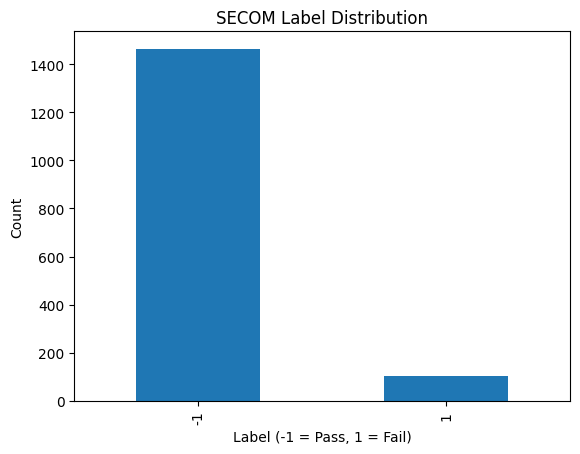

In [5]:
# reports/figures 폴더 경로를 설정합니다.
FIGURE_DIR = Path("../reports/figures")

# figures 폴더를 생성합니다.
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

# label 분포 bar plot을 생성합니다.
label_counts.plot(kind="bar")

# 그래프 제목과 축 이름을 설정합니다.
plt.title("SECOM Label Distribution")
plt.xlabel("Label (-1 = Pass, 1 = Fail)")
plt.ylabel("Count")

# 그래프를 이미지 파일로 저장합니다.
plt.savefig(FIGURE_DIR / "label_distribution.png", bbox_inches="tight", dpi=150)

# 그래프를 화면에 표시합니다.
plt.show()

In [4]:
missing_by_feature = X.isna().mean().sort_values(ascending=False)

display(missing_by_feature.head(20).to_frame("missing_ratio"))

print("Number of features:", X.shape[1])
print("Features with missing values:", (missing_by_feature > 0).sum())
print("Features with all missing values:", (missing_by_feature == 1).sum())

,missing_ratio
292,0.911934
293,0.911934
158,0.911934
157,0.911934
492,0.855775
85,0.855775
358,0.855775
220,0.855775
244,0.649649
517,0.649649


Number of features: 590
Features with missing values: 538
Features with all missing values: 0


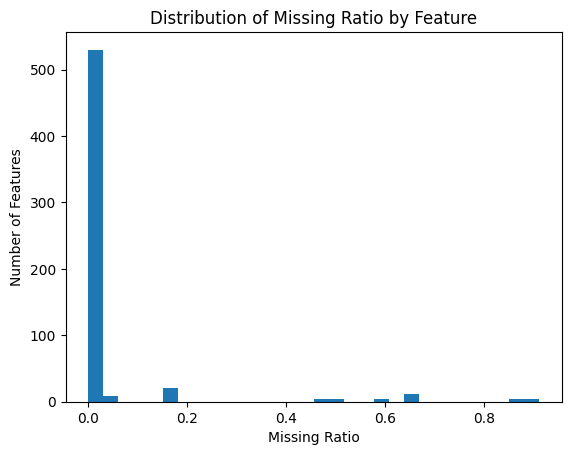

In [6]:
# feature별 결측률 분포를 histogram으로 표시합니다.
missing_by_feature.plot(kind="hist", bins=30)

# 그래프 제목과 축 이름을 설정합니다.
plt.title("Distribution of Missing Ratio by Feature")
plt.xlabel("Missing Ratio")
plt.ylabel("Number of Features")

# 그래프를 이미지 파일로 저장합니다.
plt.savefig(FIGURE_DIR / "feature_missing_ratio_distribution.png", bbox_inches="tight", dpi=150)

# 그래프를 화면에 표시합니다.
plt.show()

,missing_ratio_by_sample
count,1567.000000
mean,0.045375
std,0.022674
min,0.006780
25%,0.033898
50%,0.040678
75%,0.054237
max,0.257627


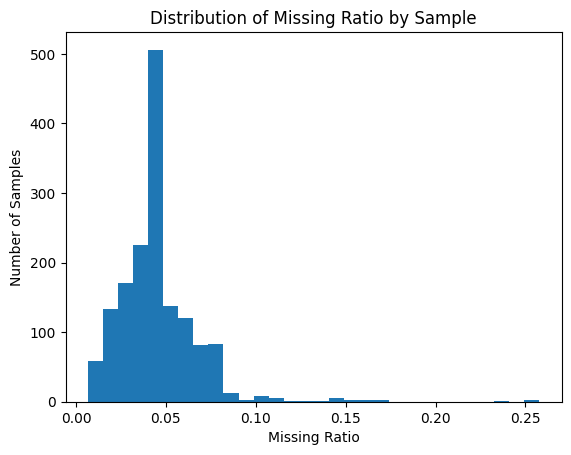

In [7]:
# sample별 결측률을 계산합니다.
missing_by_sample = X.isna().mean(axis=1)

# sample별 결측률 기초 통계를 출력합니다.
display(missing_by_sample.describe().to_frame("missing_ratio_by_sample"))

# sample별 결측률 분포를 histogram으로 표시합니다.
missing_by_sample.plot(kind="hist", bins=30)

# 그래프 제목과 축 이름을 설정합니다.
plt.title("Distribution of Missing Ratio by Sample")
plt.xlabel("Missing Ratio")
plt.ylabel("Number of Samples")

# 그래프를 이미지 파일로 저장합니다.
plt.savefig(FIGURE_DIR / "sample_missing_ratio_distribution.png", bbox_inches="tight", dpi=150)

# 그래프를 화면에 표시합니다.
plt.show()